In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00a 0:00:01


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files[:5]:
        print("  ", file)

/kaggle/input
/kaggle/input/traffic-detection-for-yolov5
   README.dataset.txt
   README.roboflow.txt
   data.yaml
/kaggle/input/traffic-detection-for-yolov5/labels
/kaggle/input/traffic-detection-for-yolov5/labels/val
   Navid_160_jpg.rf.4883e78f869b85ecd26251f14d01304e.txt
   Dipto_783_jpg.rf.239bd3d53617d6496db5458e416c0f57.txt
   Pias--211-_jpg.rf.42ab73fdee812d4b302f0c1117b569a7.txt
   Pias--118-_jpg.rf.762746241ba51195c471f0d244b6bff3.txt
   Numan_-343-_jpg.rf.e85d6c52a44af34351ab30d69e17538e.txt
/kaggle/input/traffic-detection-for-yolov5/labels/train
   Dipto_770_jpg.rf.fd930a1055d1c760ea2bb805305b55c8.txt
   Numan_-174-_jpg.rf.d1b682e093990d49fd2f3a100d8b2110.txt
   Navid_789_jpg.rf.de52c9d13d2ad8fdf2ef67085b95692a.txt
   Pias--487-_jpg.rf.aa786ef15f1984d2c0005eddae1fcd1f.txt
   Pias--190-_jpg.rf.b9a5a551c70c04996832acb0de839b89.txt
/kaggle/input/traffic-detection-for-yolov5/images
/kaggle/input/traffic-detection-for-yolov5/images/val
   Dipto_-332_jpg.rf.feb757f6812386689b530d

In [5]:
model = YOLO("yolov8n.pt")


Text(0.5, 1.0, 'Sample Traffic Image')

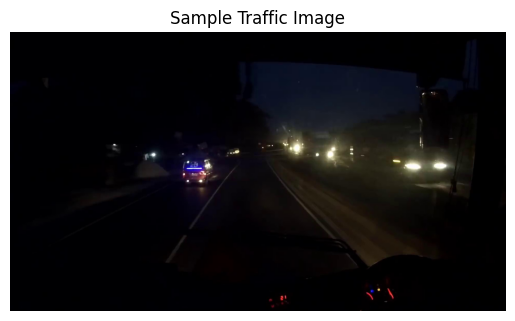

In [6]:
img_dir = "/kaggle/input/traffic-detection-for-yolov5/images/val"
img_name = os.listdir(img_dir)[0]

image_path = os.path.join(img_dir, img_name)
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError("Image not loaded. Check dataset path.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.title("Sample Traffic Image")


In [7]:
def detect_car_color(car_img):
    hsv = cv2.cvtColor(car_img, cv2.COLOR_BGR2HSV)

    blue_lower = np.array([100, 150, 50])
    blue_upper = np.array([130, 255, 255])

    blue_mask = cv2.inRange(hsv, blue_lower, blue_upper)

    blue_pixels = cv2.countNonZero(blue_mask)
    total_pixels = car_img.shape[0] * car_img.shape[1]

    blue_ratio = blue_pixels / total_pixels

    if blue_ratio > 0.08:
        return "Blue"
    else:
        return "Not Blue"


In [8]:
results = model(image)[0]
car_count = 0
people_count = 0


0: 384x640 1 car, 1 traffic light, 268.3ms
Speed: 8.8ms preprocess, 268.3ms inference, 21.8ms postprocess per image at shape (1, 3, 384, 640)


In [9]:
for box in results.boxes:
    cls = int(box.cls[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    label = model.names[cls]

    if label == "car":
        car_count += 1
        car_img = image[y1:y2, x1:x2]

        if car_img.size == 0:
            continue

        car_color = detect_car_color(car_img)

        if car_color == "Blue":
            box_color = (0, 0, 255)  # Red box
        else:
            box_color = (255, 0, 0)  # Blue box

        cv2.rectangle(image, (x1, y1), (x2, y2), box_color, 2)
        cv2.putText(image, car_color, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    elif label == "person":
        people_count += 1
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)


In [10]:
cv2.putText(image, f"Cars Count: {car_count}", (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

cv2.putText(image, f"People Count: {people_count}", (20, 80),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)


array([[[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[2, 0, 0],
        [2, 0, 0],
        [2, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

Text(0.5, 1.0, 'Car Colour Detection & Traffic Counting Result')

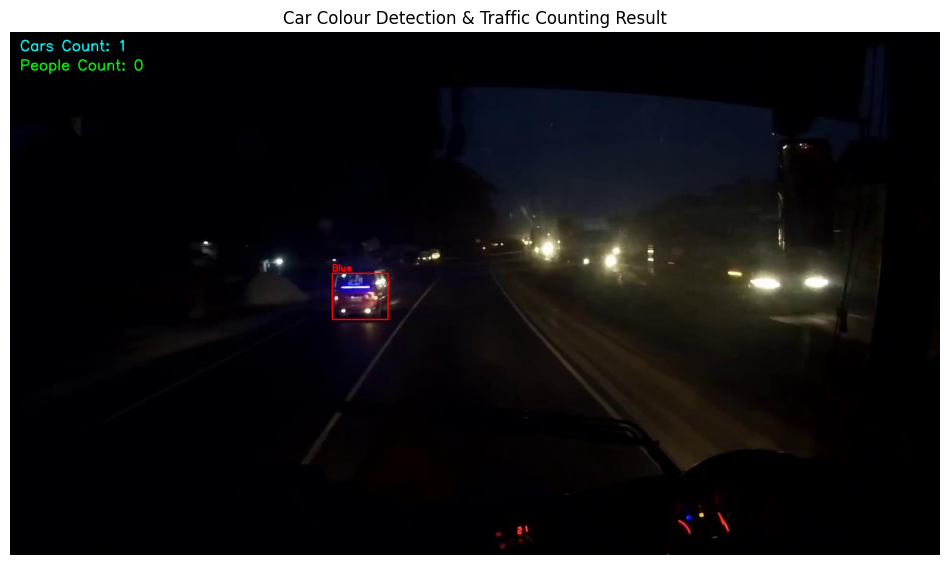

In [11]:
final_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(final_image)
plt.axis("off")
plt.title("Car Colour Detection & Traffic Counting Result")
